## Micron Technologies Earnings Modeling

## Feature Engineering and transformations

* Compute the financial metrics using the fundamental data
* Get the next 5 trading day returns and discretize them into 4 buckets. Extreme positive and negative days, and normal losses and gains. This will act as the dependent variable to be predicted
* Scale the features

### PCA

### LDA

### Decision Trees

In [20]:
from datetime import datetime, date, timedelta
import requests
import pandas as pd
from dateutil import parser
import numpy as np
import csv
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import yfinance as yf
from scipy.stats import gaussian_kde
import statsmodels.api as sm
from KDEpy import FFTKDE
from scipy.interpolate import interp1d
from KDEpy.bw_selection import silvermans_rule
from s3io import S3IO
from alpha_utils import get_bucket_name, get_profile_name
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

## Feature Engineering

In [3]:
# Step 1: Download OSK daily historical data
portfolio_tickers = [
    "OSK"
]
dfs = []
for ticker in portfolio_tickers:
    df_tmp = yf.Ticker(ticker)
    # Download historical price data
    historical_data = df_tmp.history(period="max", interval="1d")
    historical_data['ticker'] = ticker
    # Display the first few rows
    dfs.append(historical_data)

osk = dfs[0]

osk['Log_Returns'] = np.log(osk['Close'] / osk['Close'].shift(1))
osk.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,Log_Returns
Date,,,,,,,,,
1985-10-02 00:00:00-04:00,1.370370,1.390823,1.370370,1.370370,4849200,0.0,0.0,OSK,NaN
1985-10-03 00:00:00-04:00,1.390824,1.411277,1.390824,1.390824,1974000,0.0,0.0,OSK,0.014816
1985-10-04 00:00:00-04:00,1.390824,1.411277,1.390824,1.390824,694800,0.0,0.0,OSK,0.000000
1985-10-07 00:00:00-04:00,1.390823,1.390823,1.370370,1.370370,337200,0.0,0.0,OSK,-0.014816
1985-10-08 00:00:00-04:00,1.370370,1.390823,1.370370,1.370370,436200,0.0,0.0,OSK,0.000000


In [4]:
# filter to the last 4 years
osk = osk.reset_index()
osk

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,Log_Returns
0,1985-10-02 00:00:00-04:00,1.370370,1.390823,1.370370,1.370370,4849200,0.0,0.0,OSK,NaN
1,1985-10-03 00:00:00-04:00,1.390824,1.411277,1.390824,1.390824,1974000,0.0,0.0,OSK,0.014816
2,1985-10-04 00:00:00-04:00,1.390824,1.411277,1.390824,1.390824,694800,0.0,0.0,OSK,0.000000
3,1985-10-07 00:00:00-04:00,1.390823,1.390823,1.370370,1.370370,337200,0.0,0.0,OSK,-0.014816
4,1985-10-08 00:00:00-04:00,1.370370,1.390823,1.370370,1.370370,436200,0.0,0.0,OSK,0.000000
...,...,...,...,...,...,...,...,...,...,...
10030,2025-07-25 00:00:00-04:00,128.440002,129.149994,126.970001,128.710007,373400,0.0,0.0,OSK,0.006861
10031,2025-07-28 00:00:00-04:00,128.949997,130.429993,128.259995,129.500000,583700,0.0,0.0,OSK,0.006119
10032,2025-07-29 00:00:00-04:00,130.429993,130.429993,125.470001,126.449997,710700,0.0,0.0,OSK,-0.023834
10033,2025-07-30 00:00:00-04:00,126.699997,127.470001,124.570000,125.480003,735900,0.0,0.0,OSK,-0.007701


In [5]:
osk_filtered = osk[osk["Date"] >= "2021-01-01"]
osk_filtered

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,Log_Returns
8886,2021-01-04 00:00:00-05:00,80.449221,81.332356,78.050802,79.082680,399100,0.0,0.0,OSK,-0.011686
8887,2021-01-05 00:00:00-05:00,78.887470,81.090669,78.887470,80.542191,541300,0.0,0.0,OSK,0.018287
8888,2021-01-06 00:00:00-05:00,81.806480,86.547535,81.806480,85.264664,1336700,0.0,0.0,OSK,0.056979
8889,2021-01-07 00:00:00-05:00,86.212860,86.445265,85.041545,85.915382,1023600,0.0,0.0,OSK,0.007603
8890,2021-01-08 00:00:00-05:00,86.463863,86.463863,84.418697,85.552834,545500,0.0,0.0,OSK,-0.004229
...,...,...,...,...,...,...,...,...,...,...
10030,2025-07-25 00:00:00-04:00,128.440002,129.149994,126.970001,128.710007,373400,0.0,0.0,OSK,0.006861
10031,2025-07-28 00:00:00-04:00,128.949997,130.429993,128.259995,129.500000,583700,0.0,0.0,OSK,0.006119
10032,2025-07-29 00:00:00-04:00,130.429993,130.429993,125.470001,126.449997,710700,0.0,0.0,OSK,-0.023834
10033,2025-07-30 00:00:00-04:00,126.699997,127.470001,124.570000,125.480003,735900,0.0,0.0,OSK,-0.007701


<Axes: xlabel='Log_Returns', ylabel='Count'>

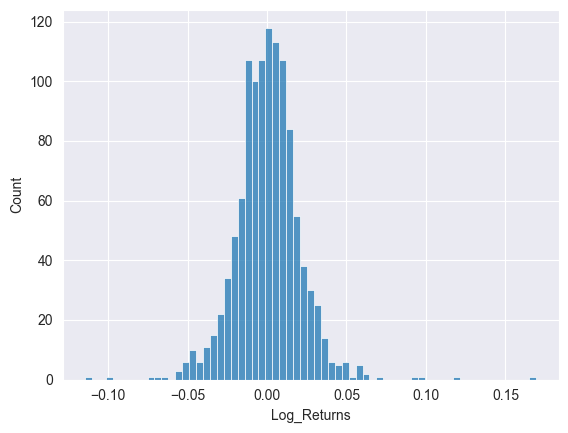

In [6]:
# plot the distribution of log retruns
sns.histplot(osk_filtered, x="Log_Returns")

<Axes: ylabel='Log_Returns'>

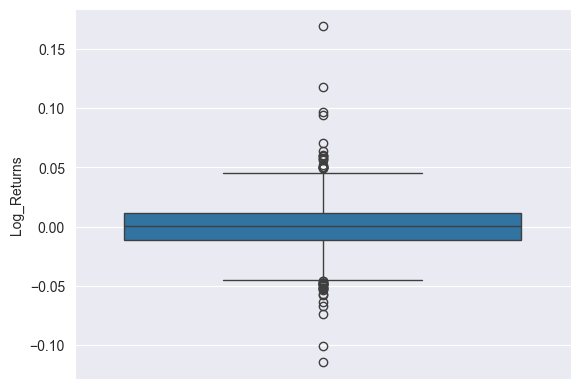

In [7]:
sns.boxplot(osk_filtered, y="Log_Returns")

(array([19113.16666667, 19236.16666667, 19358.20833333, 19478.16666667,
        19601.16666667, 19723.20833333, 19844.16666667, 19967.16666667,
        20089.20833333, 20209.16666667, 20332.16666667]),
 [Text(19113.166666666668, 0, '2022-05'),
  Text(19236.166666666668, 0, '2022-09'),
  Text(19358.208333333332, 0, '2023-01'),
  Text(19478.166666666668, 0, '2023-05'),
  Text(19601.166666666668, 0, '2023-09'),
  Text(19723.208333333332, 0, '2024-01'),
  Text(19844.166666666668, 0, '2024-05'),
  Text(19967.166666666668, 0, '2024-09'),
  Text(20089.208333333332, 0, '2025-01'),
  Text(20209.166666666668, 0, '2025-05'),
  Text(20332.166666666668, 0, '2025-09')])

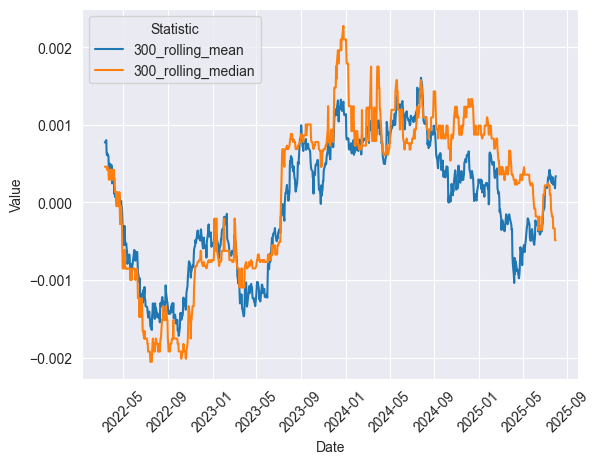

In [13]:
# # Create a rolling window of the mean and median
# osk_filtered['300_rolling_mean'] = osk_filtered['Log_Returns'].rolling(window=300).mean()
# osk_filtered['300_rolling_median'] = osk_filtered['Log_Returns'].rolling(window=300).median()
#
# # generate a line plot of the two
# plot_mean_median = osk_filtered[["Date", "300_rolling_mean", "300_rolling_median"]].melt(id_vars=['Date'],
#                                                                                          value_vars=['300_rolling_mean', '300_rolling_median'],
#                                                                                          var_name='Statistic',
#                                                                                          value_name='Value')
sns.lineplot(plot_mean_median, x="Date", y="Value", hue="Statistic")
plt.xticks(rotation=45)

<Axes: ylabel='Density'>

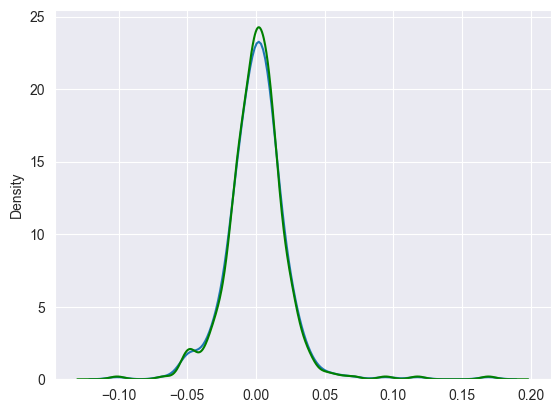

In [15]:
# fit a KDE estimator to the log returns of the last year
osk_filtered2 = osk[osk["Date"] >= "2024-01-01"]
kde = FFTKDE(bw='silverman').fit(osk_filtered2['Log_Returns'].to_numpy())
xde, ykde = kde.evaluate()

sns.kdeplot(osk_filtered2['Log_Returns'].to_numpy())
sns.lineplot(x=xde, y=ykde, color='g')


In [22]:
number_days = 54
data = osk_filtered2['Log_Returns'].to_numpy()
mean = osk_filtered2['Log_Returns'].mean()
variance = osk_filtered2['Log_Returns'].var()
standard_dev = osk_filtered2['Log_Returns'].std()
drift = mean - (0.5 * variance)


# estimate the cdf
dx = np.diff(xde)[0]
cdf = np.cumsum(ykde) * dx
cdf /= cdf[-1]
current_price = 127.55

ppf = interp1d(cdf, xde, bounds_error=False, fill_value=(xde[0], xde[-1]))

n = 10000  # number of samples
u = np.random.rand(number_days, n)  # uniform(0,1)
samples = ppf(u)

sample_log_returns = np.exp(drift + standard_dev * samples)
price_paths = np.zeros_like(sample_log_returns)
price_paths[0] = current_price

for t in range(1, number_days):
    price_paths[t] = price_paths[t - 1] * sample_log_returns[t]

predictions = price_paths.T
columns = []
for i in range(number_days):
    columns.append(f'day_{i + 1}')

df_predictions = pd.DataFrame(predictions, columns=columns)
df_predictions

,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,...,day_45,day_46,day_47,day_48,day_49,day_50,day_51,day_52,day_53,day_54
0,127.55,127.519728,127.629905,127.656945,127.708983,127.670954,127.667479,127.590546,127.596141,127.644429,...,128.428025,128.489113,128.494864,128.544209,128.579844,128.648142,128.647816,128.607696,128.645950,128.658094
1,127.55,127.610864,127.634252,127.712441,127.753159,127.802727,127.740015,127.790702,127.797192,127.821315,...,129.602899,129.626730,129.503810,129.553583,129.592857,129.649364,129.518420,129.464698,129.501676,129.547277
2,127.55,127.639136,127.681568,127.713216,127.601097,127.591389,127.608338,127.599371,127.616910,127.680746,...,128.338050,128.402698,128.454451,128.459429,128.395273,128.397960,128.408949,128.450182,128.483506,128.518769
3,127.55,127.604858,127.665736,127.698825,127.700464,127.756166,127.766967,127.768484,127.844893,127.921348,...,128.684970,128.748688,128.753909,128.803034,128.817432,128.835693,128.868763,128.814579,128.889098,128.990823
4,127.55,127.606108,127.623470,127.641488,127.530867,127.527907,127.617997,127.625374,127.707445,127.753633,...,128.298084,128.328843,128.325677,128.386990,128.423310,128.433192,128.471997,128.503161,128.487749,128.787900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,127.55,127.624166,127.685848,127.769952,127.828107,127.899362,127.961650,128.111573,128.219625,128.213292,...,129.229209,129.281564,129.354807,129.361696,129.448144,129.554934,129.632162,129.660392,129.783418,129.958397
9996,127.55,127.561195,127.604069,127.637516,127.716837,127.756409,127.699797,127.818620,127.847819,127.877213,...,129.160193,129.298409,129.269808,129.566389,129.423553,129.424074,129.459218,129.502390,129.474906,129.509281
9997,127.55,127.584700,127.673120,127.750042,127.779728,127.812631,127.723092,127.714237,127.662600,127.689080,...,128.806806,128.896015,128.952313,128.918300,128.903557,128.922136,128.995407,129.030430,129.016570,129.091989
9998,127.55,127.614542,127.604264,127.666681,127.623965,127.608385,127.529808,127.575803,127.575721,127.716582,...,128.489514,128.571341,128.578914,128.544907,128.583292,128.582859,128.487078,128.506821,128.540815,128.636229


<Axes: xlabel='day_54', ylabel='Count'>

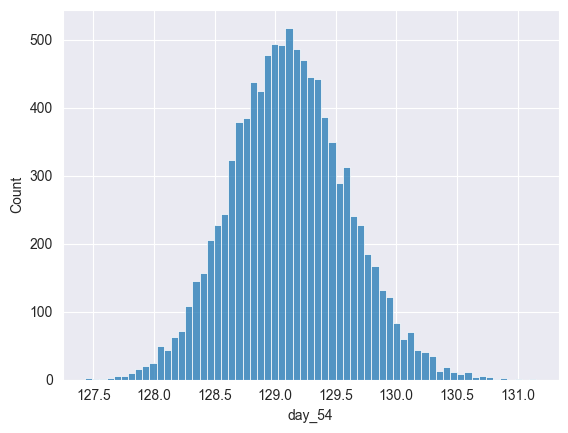

In [23]:
sns.histplot(df_predictions, x="day_54")